# **Bloque 1: Instalación e importación de librerías**

In [ ]:

# Bloque 1: Importar librerías necesarias
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans, DBSCAN, SpectralClustering
from sklearn.metrics import adjusted_rand_score, v_measure_score, silhouette_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


# **Bloque 2: Cargar y escalar el dataset Iris, y visualización con PCA**

Este código estandariza los datos de las flores, los comprime a dos dimensiones mediante PCA y genera un gráfico que permite visualizar claramente cómo se agrupan las tres especies, facilitando la comprensión de su estructura natural.

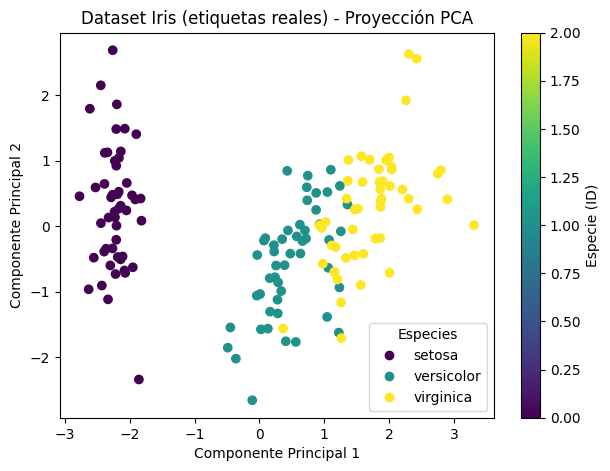

Datos cargados y escalados. Dimensiones de los datos originales: (150, 4)


In [ ]:
# =====================================================
# BLOQUE 2: Cargar datos, escalar y visualizar con PCA
# =====================================================

# Iris contiene 150 muestras de flores con 4 características (largo/ancho de sépalo y pétalo)
# y 3 especies objetivo (setosa, versicolor, virginica).
iris = load_iris()
datosX = iris.data
etiquetasReales = iris.target

# Escalar: necesario para algoritmos basados en distancia (media=0, desviación=1)
escalador = StandardScaler()
datosXEscalados = escalador.fit_transform(datosX)

# Reducción a 2D para visualización (PCA)
pca = PCA(n_components=2, random_state=42)
datosX_PCA = pca.fit_transform(datosXEscalados)

# Graficar
plt.figure(figsize=(7,5)) # Aumenté un poco el ancho para que quepa todo
scatter = plt.scatter(datosX_PCA[:,0], datosX_PCA[:,1], c=etiquetasReales, cmap='viridis')

#leyenda de especies
plt.legend(handles=scatter.legend_elements()[0], labels=list(iris.target_names), title="Especies")

#barra de color
plt.colorbar(scatter, label='Especie (ID)')

plt.title('Dataset Iris (etiquetas reales) - Proyección PCA')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.show()

print("Datos cargados y escalados. Dimensiones de los datos originales:", datosXEscalados.shape)

# **Bloque 3: Método del codo (Elbow Method) para K-means**
Aqui se aplica el método del codo para encontrar el número ideal de grupos, probando de 1 a 10 agrupaciones y calculando el "error" (inercia) de cada una; al graficar estos resultados, permite identificar visualmente el punto donde añadir más grupos deja de ser eficiente.

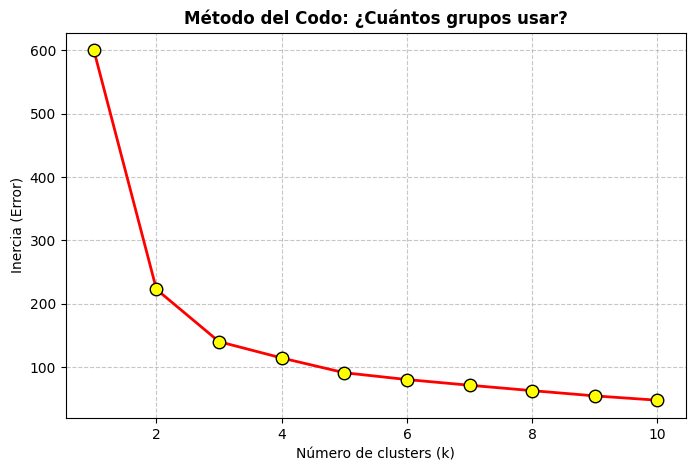

In [ ]:
# =====================================================
# BLOQUE 3: Método del codo para determinar k óptimo
# =====================================================
valoresInercia = []
rangoK = range(1, 11)

for k in rangoK:
    # Probamos de 1 a 10 grupos para ver cuál organiza mejor los datos.
    modelo = KMeans(n_clusters=k, random_state=42, n_init=20)
    modelo.fit(datosXEscalados)

    # La inercia es el error; buscamos reducirlo al agrupar los datos.
    valoresInercia.append(modelo.inertia_)

plt.figure(figsize=(8, 5))

# Visualizamos la curva: el "codo" indicará el número ideal de grupos.
plt.plot(rangoK, valoresInercia, marker='o', color='red',
         markerfacecolor='yellow', markeredgecolor='black', markersize=9, linewidth=2)

plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia (Error)')

# El "codo" es el punto donde dejar de añadir grupos es lo más eficiente.
plt.title('Método del Codo: ¿Cuántos grupos usar?', fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

# **Bloque 4: Entrenar los tres modelos (K-means, DBSCAN, SpectralClustering)**
Este bloque entrena tres algoritmos diferentes para agrupar los datos (K-means, DBSCAN y Spectral Clustering), permitiendo comparar cómo cada uno identifica estructuras distintas, desde centros definidos y densidades locales hasta conexiones complejas entre puntos.

In [ ]:
# =====================================================
# BLOQUE 4: Entrenar modelos de agrupamiento
# =====================================================

# K-means: Agrupa los datos en 3 centros definidos buscando minimizar la distancia entre puntos.
modeloKmeans = KMeans(n_clusters=3, random_state=42, n_init=20, max_iter=500)
etiquetasKmeans = modeloKmeans.fit_predict(datosXEscalados)

# DBSCAN: Agrupa por densidad de puntos. Detecta ruido automáticamente si no encuentra vecinos cercanos.
modeloDbscan = DBSCAN(eps=0.5, min_samples=5)
etiquetasDbscan = modeloDbscan.fit_predict(datosXEscalados)

# SpectralClustering: Usa la estructura del grafo de los datos para agrupar, ideal para formas complejas.
modeloSpectral = SpectralClustering(n_clusters=3, affinity='rbf', gamma=1.0, random_state=42)
etiquetasSpectral = modeloSpectral.fit_predict(datosXEscalados)

print("Modelos entrenados correctamente.")
print(f"Clusters encontrados por DBSCAN: {len(set(etiquetasDbscan)) - (1 if -1 in etiquetasDbscan else 0)}")
print(f"Puntos considerados ruido por DBSCAN: {np.sum(etiquetasDbscan == -1)}")

Modelos entrenados correctamente.
Clusters encontrados por DBSCAN: 2
Puntos considerados ruido por DBSCAN: 34


# **Bloque 5: Visualización de los resultados (con PCA)**
Este código organiza los resultados de los tres modelos en una comparativa visual de tres columnas, permitiendo observar gráficamente cómo cada algoritmo interpreta y clasifica la estructura de los datos en el espacio bidimensional definido por PCA.

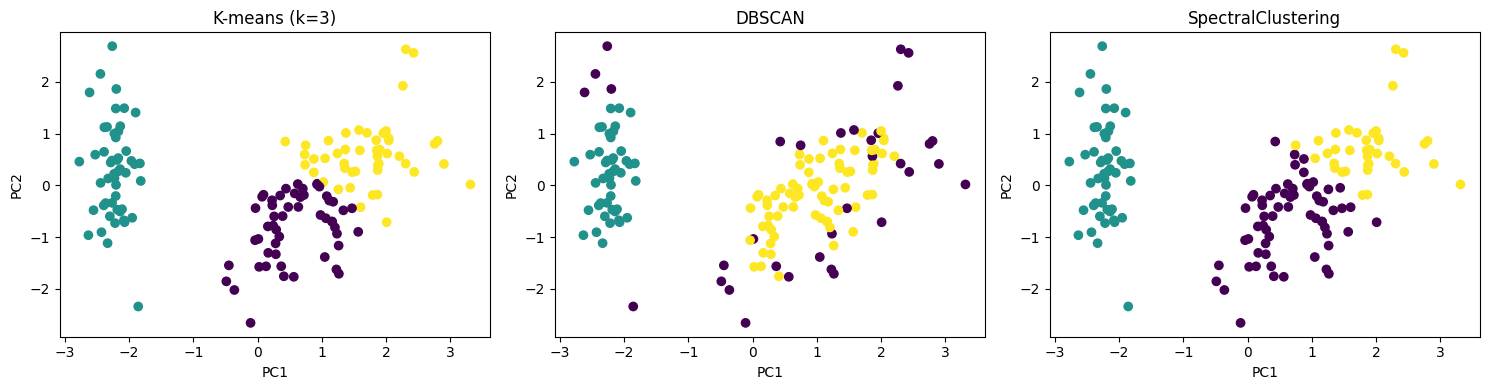

In [ ]:
# =====================================================
# BLOQUE 5: Comparativa visual de los modelos
# =====================================================

# Creamos 3 espacios (ejes) en una sola fila para comparar los resultados lado a lado.
figura, ejes = plt.subplots(1, 3, figsize=(15,4))

# 1. K-means: Muestra cómo agrupa buscando centros definidos.
ejes[0].scatter(datosX_PCA[:,0], datosX_PCA[:,1], c=etiquetasKmeans, cmap='viridis')
ejes[0].set_title('K-means (k=3)')
ejes[0].set_xlabel('PC1')
ejes[0].set_ylabel('PC2')

# 2. DBSCAN: Muestra cómo agrupa por densidad (puede dejar puntos fuera si es ruido).
ejes[1].scatter(datosX_PCA[:,0], datosX_PCA[:,1], c=etiquetasDbscan, cmap='viridis')
ejes[1].set_title('DBSCAN')
ejes[1].set_xlabel('PC1')
ejes[1].set_ylabel('PC2')

# 3. SpectralClustering: Muestra cómo agrupa usando conexiones entre puntos.
ejes[2].scatter(datosX_PCA[:,0], datosX_PCA[:,1], c=etiquetasSpectral, cmap='viridis')
ejes[2].set_title('SpectralClustering')
ejes[2].set_xlabel('PC1')
ejes[2].set_ylabel('PC2')

#GRAFICAMOS
plt.tight_layout()
plt.show()

# **Bloque 6: Calcular y mostrar métricas externas e internas**
Aqui se evalúa el desempeño de los modelos mediante métricas estadísticas que comparan la precisión de las etiquetas obtenidas frente a la realidad, además de medir qué tan bien separados y compactos quedaron los grupos formados, permitiendo determinar objetivamente cuál algoritmo es el más efectivo.

In [ ]:
# =====================================================
# BLOQUE 6: Métricas de validación para comparar modelos
# =====================================================

def calcularMetricas(nombreModelo, etiquetasPredichas):
    # ARI y V-measure: Evalúan qué tan cerca está la predicción de la realidad (etiquetas conocidas).
    ari = adjusted_rand_score(etiquetasReales, etiquetasPredichas)
    vMeasure = v_measure_score(etiquetasReales, etiquetasPredichas)

    # Silhouette y Davies-Bouldin: Evalúan la calidad interna del agrupamiento sin conocer la realidad.
    clusters_validos = [c for c in set(etiquetasPredichas) if c != -1]
    numeroClusters = len(clusters_validos)

    if numeroClusters >= 2:
        # Silhouette: Qué tan bien separados están los grupos (valor cercano a 1 es mejor).
        silhouette = silhouette_score(datosXEscalados, etiquetasPredichas)
        # Davies-Bouldin: Mide la dispersión dentro de cada cluster (valor más bajo es mejor).
        davisBouldin = davies_bouldin_score(datosXEscalados, etiquetasPredichas)
    else:
        silhouette = np.nan
        davisBouldin = np.nan

    print(f'--- {nombreModelo} ---')
    print(f'ARI (Precisión de etiquetas): {ari:.3f}')
    print(f'V-measure (Consistencia): {vMeasure:.3f}')
    print(f'Silhouette (Separación): {silhouette:.3f}')
    print(f'Davies-Bouldin (Compacidad): {davisBouldin:.3f}')
    print()

# Ejecutamos la validación para cada algoritmo entrenado
calcularMetricas('K-means', etiquetasKmeans)
calcularMetricas('DBSCAN', etiquetasDbscan)
calcularMetricas('SpectralClustering', etiquetasSpectral)

--- K-means ---
ARI (Precisión de etiquetas): 0.620
V-measure (Consistencia): 0.659
Silhouette (Separación): 0.460
Davies-Bouldin (Compacidad): 0.834

--- DBSCAN ---
ARI (Precisión de etiquetas): 0.442
V-measure (Consistencia): 0.511
Silhouette (Separación): 0.357
Davies-Bouldin (Compacidad): 7.124

--- SpectralClustering ---
ARI (Precisión de etiquetas): 0.645
V-measure (Consistencia): 0.690
Silhouette (Separación): 0.463
Davies-Bouldin (Compacidad): 0.826



# **Bloque 7 (Opcional): Comparación de inercias o guardar resultados**
genera un reporte detallado que cuantifica cuántas muestras fueron asignadas a cada grupo por cada algoritmo, identificando explícitamente los puntos detectados como "ruido" en el caso de DBSCAN, lo que permite visualizar la distribución de los resultados y la consistencia de cada modelo.

In [ ]:
# =====================================================
# BLOQUE 7: Resumen detallado de asignaciones
# =====================================================

def imprimir_resumen(nombre, etiquetas):
    print(f"--- Resumen: {nombre} ---")
    # Filtramos el ruido (-1) para DBSCAN y contamos los elementos por cluster
    etiquetas_limpias = etiquetas[etiquetas != -1]
    conteos = np.bincount(etiquetas_limpias)

    for i, cantidad in enumerate(conteos):
        print(f"  Cluster {i}: {cantidad} muestras")

    # Notificación de ruido si es DBSCAN
    ruido = np.sum(etiquetas == -1)
    if ruido > 0:
        print(f"  Ruido detectado: {ruido} muestras")
    print()

print("Distribución de flores por cluster:\n")
imprimir_resumen('K-means', etiquetasKmeans)
imprimir_resumen('DBSCAN', etiquetasDbscan)
imprimir_resumen('SpectralClustering', etiquetasSpectral)

Distribución de flores por cluster:

--- Resumen: K-means ---
  Cluster 0: 53 muestras
  Cluster 1: 50 muestras
  Cluster 2: 47 muestras

--- Resumen: DBSCAN ---
  Cluster 0: 45 muestras
  Cluster 1: 71 muestras
  Ruido detectado: 34 muestras

--- Resumen: SpectralClustering ---
  Cluster 0: 63 muestras
  Cluster 1: 50 muestras
  Cluster 2: 37 muestras

